# 05 — Modelling

Use the extracted event features to train machine learning models that classify appliance switching events.

## Model Selection Rationale

Since this is an initial NILM prototype with only 245 labeled events and a relatively small feature set, I focused on classical machine learning models.

- Logistic Regression provides a simple and interpretable baseline.
- Decision Trees offer transparent decision rules and improved flexibility.
- Random Forest extends Decision Trees through an ensemble approach, often achieving better generalization while remaining relatively easy to interpret.

These models provide a good balance between performance, interpretability, and implementation complexity for an initial NILM study.

**Key evaluation metric:** Per-appliance F1 score.

Accuracy alone does not reveal how well the model performs on each appliance class.  
We therefore focus on per-class F1 scores, which provide a better measure of classification performance across all appliance categories.



## Expected Outcome

The objective is to compare different classification algorithms and determine which model best distinguishes appliance events using the engineered features extracted in the previous notebook.

In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df = pd.read_csv('../data/processed/feature_matrix.csv')
print(df.shape)
print('Classes:', df['label'].unique())
df.head(5)

(245, 13)
Classes: ['Washer_Dryer' 'Fridge' 'Freezer' 'Computer']


,delta_power,delta_power_abs,power_before_mean,power_before_std,steady_state_mean,steady_state_std,steady_state_max,steady_state_min,rise_time_seconds,time_of_day_hour,is_nighttime,direction,label
0,70.984400,70.984400,558.048387,14.680687,629.032787,8.280433,653.0,617.0,0,13,0,1,Washer_Dryer
1,11.358012,11.358012,1810.838710,43.116970,1822.196721,107.470743,1947.0,1627.0,28,13,0,0,Fridge
2,237.425172,237.425172,2249.935484,206.114359,2487.360656,199.057951,2727.0,2146.0,0,13,0,1,Freezer
3,63.482813,63.482813,230.451613,14.280146,293.934426,3.140429,298.0,286.0,0,14,0,1,Washer_Dryer
4,-234.263882,234.263882,941.903226,27.300006,707.639344,80.078926,819.0,550.0,60,14,0,0,Fridge


In [4]:
# separate features and target
feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols]
y = df['label']

# encode string labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Classes after encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i}: {cls} ({(y == cls).sum()} events)')

Classes after encoding:
  0: Computer (57 events)
  1: Freezer (69 events)
  2: Fridge (57 events)
  3: Washer_Dryer (62 events)


### Observation

The four appliance classes are reasonably balanced, with each class contributing between 57 and 69 events. This reduces the risk of severe class imbalance during model training.

### Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

Stratified sampling is used to preserve the class distribution in both subsets, ensuring that each appliance class is represented proportionally during evaluation.

In [6]:
# stratified split — preserve class ratios in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 196 | Test: 49


In [7]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
1    55
3    49
0    46
2    46
Name: count, dtype: int64

Testing class distribution:
1    14
3    13
0    11
2    11
Name: count, dtype: int64


## Model 1: Logistic Regression

Logistic Regression is used as a baseline classifier. Since it assumes a linear decision boundary, it provides a simple and interpretable benchmark for comparing more complex models. Feature scaling is applied because the model is sensitive to feature magnitudes.

In [9]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Computer       0.65      1.00      0.79        11
     Freezer       0.50      0.29      0.36        14
      Fridge       0.33      0.45      0.38        11
Washer_Dryer       0.22      0.15      0.18        13

    accuracy                           0.45        49
   macro avg       0.43      0.47      0.43        49
weighted avg       0.42      0.45      0.41        49

Accuracy: 0.449


### My Observation

Logistic Regression achieved moderate performance, with an overall accuracy of approximately 45%.
    The model identified Computer events relatively well but struggled to distinguish between several appliance classes.

This suggests that the relationship between the extracted features and appliance labels is not purely linear.   
  More flexible models such as Decision Trees and Random Forests may capture the underlying patterns more effectively.

## Model 2: Decision Tree

Decision Trees can learn non-linear decision boundaries and are easier to interpret than many machine learning models.

To reduce overfitting, the tree depth is limited to 6 and a minimum of 3 samples is required in each leaf node.

In [11]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42, min_samples_leaf=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 3))

=== Decision Tree ===
              precision    recall  f1-score   support

    Computer       0.65      1.00      0.79        11
     Freezer       0.67      0.57      0.62        14
      Fridge       0.22      0.18      0.20        11
Washer_Dryer       0.27      0.23      0.25        13

    accuracy                           0.49        49
   macro avg       0.45      0.50      0.46        49
weighted avg       0.46      0.49      0.46        49

Accuracy: 0.49


### My Observation

The Decision Tree performed slightly better than Logistic Regression, achieving an accuracy of approximately 49%.

The model classified Computer and Freezer events reasonably well, indicating that it was able to capture some non-linear relationships in the feature space. However, performance for Fridge and Washer_Dryer events remained relatively low.

Overall, the improvement over Logistic Regression suggests that appliance classes are not perfectly linearly separable, but additional model complexity may still be needed for better classification performance.

## Model 3: Random Forest

Random Forest combines predictions from multiple decision trees to improve generalization and reduce overfitting.

The model can capture complex, non-linear relationships between features while also providing feature importance scores that help explain its predictions.

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                            min_samples_leaf=2, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))

=== Random Forest ===
              precision    recall  f1-score   support

    Computer       0.73      1.00      0.85        11
     Freezer       0.61      0.79      0.69        14
      Fridge       0.40      0.36      0.38        11
Washer_Dryer       0.50      0.23      0.32        13

    accuracy                           0.59        49
   macro avg       0.56      0.60      0.56        49
weighted avg       0.56      0.59      0.56        49

Accuracy: 0.592


### My Observation

Random Forest achieved the best performance among the three models, reaching an accuracy of approximately 59%.

The model classified Computer and Freezer events particularly well and showed consistent improvements across most appliance classes compared to Logistic Regression and Decision Tree models.

These results indicate that the relationship between appliance events and extracted features is non-linear, making ensemble tree-based methods more suitable for this classification task.

## Model Comparison

In [15]:
results = {}
for name, y_pred, model, X_t in [
    ('Logistic Regression', y_pred_lr, lr, X_test_sc),
    ('Decision Tree',       y_pred_dt, dt, X_test),
    ('Random Forest',       y_pred_rf, rf, X_test)
]:
    results[name] = {
        'Accuracy'   : accuracy_score(y_test, y_pred),
        'Macro F1'   : f1_score(y_test, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted')
    }

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)

print(results_df.round(3))

                     Accuracy  Macro F1  Weighted F1
Random Forest           0.592     0.558        0.556
Decision Tree           0.490     0.463        0.463
Logistic Regression     0.449     0.429        0.415


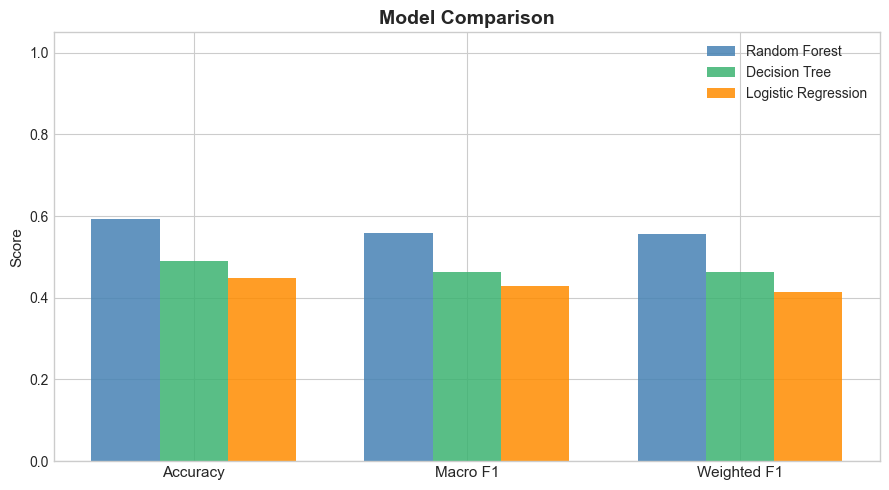

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'mediumseagreen', 'darkorange']

for i, (model_name, color) in enumerate(zip(results_df.index, colors)):
    vals = [results_df.loc[model_name, m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=model_name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/05_model_comparison.png', dpi=150)
plt.show()

### My Observation

The comparison shows a clear improvement from Logistic Regression to Decision Tree and finally Random Forest.

Random Forest achieved the highest Accuracy, Macro F1, and Weighted F1 scores, indicating that it was the most effective model for distinguishing between appliance classes.

The higher Macro F1 score suggests that Random Forest performed better across all appliance categories rather than only on the most frequent classes. Therefore, Random Forest is selected as the final model for subsequent analysis.

## Best Performing Model

Random Forest achieved the highest Accuracy, Macro F1, and Weighted F1 scores among the evaluated models.

### What this model does

The trained Random Forest model takes a detected power event and predicts which appliance caused it based on its electrical signature. This allows appliance-level insights to be obtained from a single aggregate meter, which is the central goal of NILM systems.

## Error Analysis

To better understand the strengths and weaknesses of the best-performing model, we examine its confusion matrix. This reveals which appliance classes are correctly identified and which classes are frequently confused with one another.

## Confusion Matrix — Random Forest

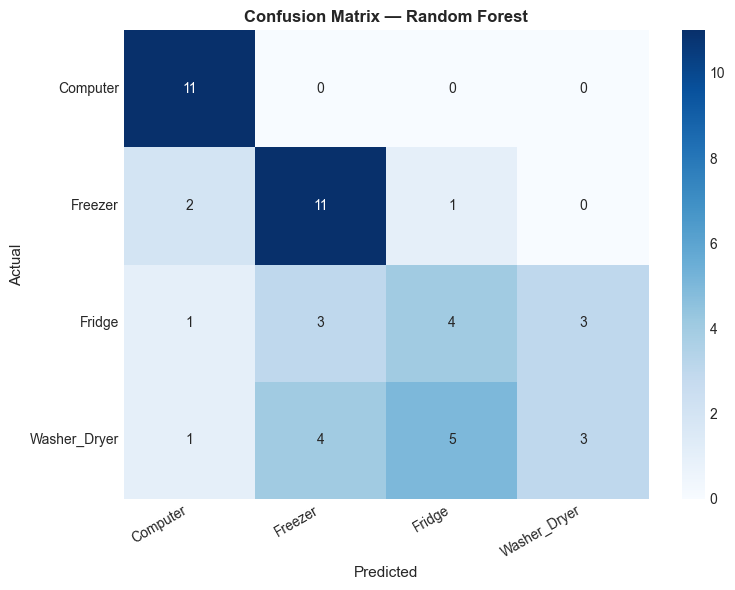

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix — Random Forest', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/05_confusion_matrix.png', dpi=150)
plt.show()

### My Observation

The confusion matrix shows that the Random Forest model identifies Computer events very accurately and performs reasonably well on Freezer events.  
Most classification errors occur between Fridge and Washer_Dryer, indicating that these appliances exhibit similar feature patterns. This explains why their F1-scores are lower than those of Computer and Freezer.  


Overall, the confusion matrix confirms that Random Forest is able to capture meaningful appliance-specific patterns, while highlighting the appliance pairs that remain difficult to separate.

## Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to appliance classification. Examining these scores helps identify which event characteristics are most useful for distinguishing between appliances.

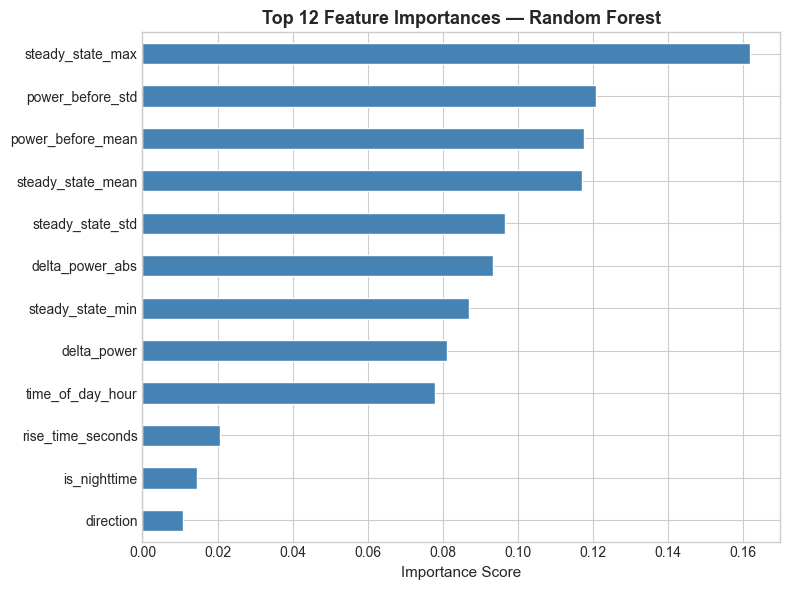

steady_state_max     0.161872
power_before_std     0.120848
power_before_mean    0.117670
steady_state_mean    0.117092
steady_state_std     0.096598
delta_power_abs      0.093456
steady_state_min     0.087135
delta_power          0.081138
time_of_day_hour     0.078110
rise_time_seconds    0.020625
is_nighttime         0.014648
direction            0.010809
dtype: float64


In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_feat = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 6))
top_feat[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Top 12 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_feature_importance.png', dpi=150)
plt.show()
print(top_feat)

### My Observations

- `steady_state_max` is the most influential feature, indicating that post-event power levels are highly informative for appliance identification.
- Steady-state statistics (`steady_state_mean`, `steady_state_std`, and `steady_state_max`) collectively contribute a large portion of the model's decision-making process.
- Power characteristics before the event (`power_before_mean` and `power_before_std`) also play an important role.
- Temporal features such as `time_of_day_hour` have moderate importance, while `is_nighttime` contributes relatively little.
- Event direction and rise time are among the least important features in this dataset.

Overall, the model relies primarily on power-related features rather than timing-related features when distinguishing between appliance classes.

## Cross-validation — verifying we didn't get lucky

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y_enc, cv=cv, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Per-fold: {cv_scores.round(3)}')

5-Fold CV Accuracy: 0.637 ± 0.079
Per-fold: [0.531 0.673 0.653 0.571 0.755]




# Summary

Random Forest achieved the strongest overall performance among the evaluated models, obtaining the highest Accuracy, Macro F1, and Weighted F1 scores.

The feature importance analysis revealed that power-related features such as `steady_state_max`, `power_before_mean`, `power_before_std`, and `steady_state_mean` contributed most to appliance classification. Temporal features and event direction were comparatively less influential.

The confusion matrix showed that Computer and Freezer events were identified more reliably, while Fridge and Washer_Dryer events were frequently confused due to similar power signatures.

Overall, the project demonstrates that appliance switching events can be classified directly from aggregate power measurements using engineered event features and classical machine learning techniques.




# Conclusion

In this notebook, I trained and evaluated three machine learning models for appliance identification using the event-level feature matrix created in the previous stage.

Among the evaluated models, Random Forest achieved the best performance, outperforming Logistic Regression and Decision Tree across multiple evaluation metrics. Feature importance analysis showed that steady-state power characteristics were the most informative predictors of appliance identity.

The results demonstrate that meaningful appliance classification can be achieved from aggregate power data without directly observing individual appliance measurements. While some appliance classes remain difficult to separate, the project establishes a complete NILM pipeline consisting of event detection, feature engineering, and appliance classification.